In [9]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
%matplotlib inline



In [20]:
train_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/train_augmented/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42
)


Found 33336 files belonging to 4 classes.


In [18]:
val_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42
)



Found 2083 files belonging to 4 classes.


In [19]:
test_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42
)

Found 2084 files belonging to 4 classes.


In [2]:
from tensorflow.keras.callbacks import Callback
from timeit import default_timer as timer

class TimingCallback(Callback):
    def __init__(self, logs={}):
        self.logs=[]
    def on_epoch_begin(self, epoch, logs={}):
        self.starttime = timer()
    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(timer()-self.starttime)

In [3]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stopping = EarlyStopping(
                                patience=5, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)

time_callback = TimingCallback()

In [22]:
# Instanciation des couches
inputs = Input(shape=(299, 299, 1), name="Input")



first_layer = Conv2D(
    filters=32,
    kernel_size=(5, 5),
    padding='valid',
    activation='relu',
    name='conv_layer1',
)

second_layer = MaxPooling2D(
    pool_size=(2, 2),
    name='max_pooling_layer'
)

third_layer = Dropout(rate=0.2)

fourth_layer = Flatten()

fifth_layer = Dense(
    units=128,
    activation='relu',
    name='dense_hidden_layer'
)

output_layer = Dense(
    units=4,
    activation='softmax',
    name='output_layer'
)


In [23]:
# Utilisation des couches
x = first_layer(inputs)
x = second_layer(x)
x = third_layer(x)
x = fourth_layer(x)
x = fifth_layer(x)



# Création du modèle
outputs = output_layer(x)
model = Model(inputs=inputs, outputs=outputs)

In [ ]:
model.compile(loss='categorical_crossentropy', # fonction de perte
              optimizer='adam',                # algorithme d'optimisation
              metrics=['accuracy']255)            # métrique d'évaluation

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=50,
                          callbacks = [reduce_learning_rate,
                                       early_stopping,
                                       time_callback]) 

Epoch 1/50


ValueError: Exception encountered when calling Functional.call().

[1mInput 0 of layer "conv_layer1" is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (None, 299, 299, 3)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(None, 299, 299, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

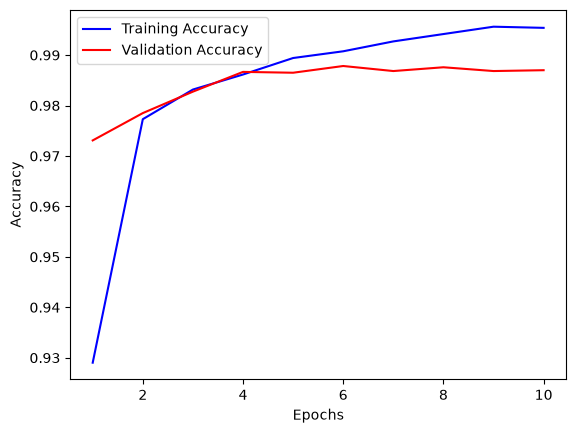

In [ ]:
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 11, 1),
         training_history.history['accuracy'],
         label='Training Accuracy',
         color='blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 11, 1),
         training_history.history['val_accuracy'], 
         label='Validation Accuracy',
         color='red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()

In [ ]:
test_pred = model.predict(X_test)

test_pred_class = test_pred.argmax(axis=1)
y_test_class = y_test.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



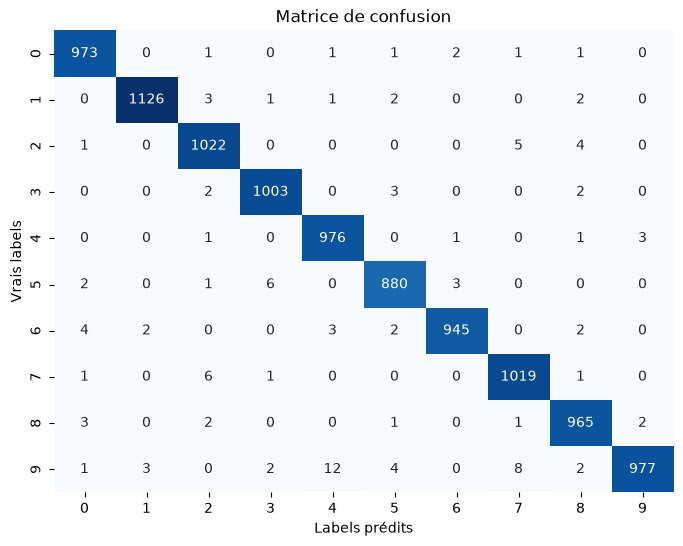

In [ ]:
print(metrics.classification_report(y_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

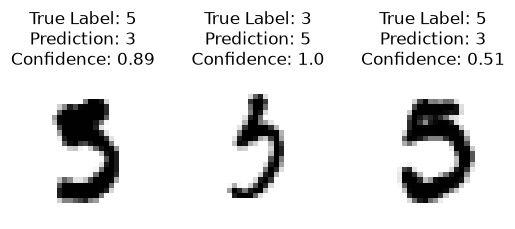

In [ ]:
error_indexes = []
for i in range(len(test_pred)):
    if (test_pred_class[i] != y_test_class[i]):
        if(y_test_class[i] == 5 or y_test_class[i] == 3):
            if(test_pred_class[i] == 5 or test_pred_class[i] == 3):
                error_indexes += [i]

j = 1
for i in np.random.choice(error_indexes, size = 3):
    img = X_test[i] 
    img = img.reshape(28, 28)
    
    plt.subplot(1, 3, j)
    j = j + 1
    plt.axis('off')
    plt.imshow(img, cmap=cm.binary, interpolation='None')
    plt.title('True Label: ' + str(y_test_class[i]) \
              + '\n' + 'Prediction: '+ str(test_pred_class[i]) \
              + '\n' + 'Confidence: '+ str(round(test_pred[i][test_pred_class[i]], 2)))